<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8012/blob/main/laboratorioCalificado5_v2.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio Calificado N° 5: Inpainting con U-Net sobre Oxford-IIIT Pet + Máscaras irregulares

**Programa:** Maestría en Ciencia de Datos e Inteligencia Artificial  
**Curso:** Visión Computacional  
**Integrantes:**
* David Jimenez
* José Carlos Nomberto


# Objetivo:
Entrenar desde cero una red convolucional U-Net para realizar tareas de Inpainting utilizando el dataset Oxford-IIIT Pet e introduciendo máscaras irregulares aleatorias.

## 1. Configuración del Entorno, Librerías y Semillas

In [18]:
import os
import random
import pathlib
import zipfile
import cv2
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import PIL
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

print("1. Configuración de Entorno, Librerías y Semillas ...")

# Configuración de hiperparámetros
CFG = {
    'BATCH': 16,
    'EPOCHS': 50,    # Limite máximo de epocas por restricción del enunciado del laboratorio
    'LR': 1e-4,
    'IMG_SIZE': 256, # Tamaño de las imágenes de entrada
    'MASK_SIZE': 224 # Tamaño de las máscaras de entrada
}

# Fijar semillas para reproducibilidad
SEED = 16
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo de entrenamiento seleccionado:', device)

1. Configuración de Entorno, Librerías y Semillas ...
Dispositivo de entrenamiento seleccionado: cuda


## 2. Descomprimir el Dataset

In [6]:
# Descomprimir el archivo de datos

# Descomprime archivo zip de y muestra cantidad de imágenes
print("2. Preparación del Dataset ...")
if os.path.exists('pet_dataset.zip'):
    print("  - Descomprimiendo Imágenes ...")
    with zipfile.ZipFile('pet_dataset.zip', 'r') as z:
        z.extractall('./')
img_dir = pathlib.Path('pet_dataset/content/pet_dataset/images')
print(f'    Cantidad de Imágenes cargadas: {len(os.listdir(img_dir))}')

# Descomprime archivo zip de y muestra cantidad de máscaras irregulares
if os.path.exists('irregular_masks.zip'):
    print("  - Descomprimiendo Máscaras ...")
    with zipfile.ZipFile('irregular_masks.zip', 'r') as z:
        z.extractall('./irregular_masks')
mask_dir = pathlib.Path('irregular_masks/irregular_masks')

print(f'    Cantidad de Máscaras cargadas: {len(os.listdir(mask_dir))}')

2. Preparación del Dataset ...
  - Descomprimiendo Imágenes ...
    Cantidad de Imágenes cargadas: 665
  - Descomprimiendo Máscaras ...
    Cantidad de Máscaras cargadas: 3122


## 3. Preparación del Dataset

In [33]:
class InpaintingDataset(Dataset):
    """
    Clase personalizada para la carga del dataset Oxford-IIIT Pet y Máscaras Irregulares.
    Genera de forma dinámica las imágenes con huecos aplicando máscaras aleatorias.
    """
    def __init__(self, img_paths, mask_dir, img_size=256, mask_size=224, transform=None):
        self.img_paths = img_paths
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])
        self.img_size = img_size
        self.mask_size = mask_size
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Cargar y redimensionar imagen original (Ground Truth)
        img_path = self.img_paths[idx]
        rgb = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, (self.img_size, self.img_size))
        rgb_normalized = rgb.astype(np.float32) / 255.0

        # Seleccionar una máscara aleatoria y redimensionarla
        mask_path = random.choice(self.mask_paths)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        # Binarizar máscara: Blanco (255) -> 1.0 (conservar), Negro (0) -> 0.0 (hueco)
        mask = (mask > 127).astype(np.float32)

        # Aplicar flip horizontal aleatorio para aumentación de datos
        if random.random() > 0.5:
            rgb_normalized = np.flip(rgb_normalized, axis=1).copy()
            mask = np.flip(mask, axis=1).copy()

        # Generar imagen con huecos aplicando la máscara binaria
        img_masked = rgb_normalized * mask[..., np.newaxis]

        # Generar la máscara invertida (Donde 1 indica la zona del hueco a reconstruir)
        mask_inverted = 1.0 - mask

        # Conversión de matrices a tensores de PyTorch (Channel, Height, Width)
        img_masked_t = torch.from_numpy(img_masked.transpose(2, 0, 1)).float()
        rgb_target_t = torch.from_numpy(rgb_normalized.transpose(2, 0, 1)).float()
        mask_inverted_t = torch.from_numpy(mask_inverted).float().unsqueeze(0)

        return img_masked_t, rgb_target_t, mask_inverted_t

# Separación del dataset en entrenamiento, validación y prueba (70/15/15)
all_imgs = sorted(list(img_dir.glob('*.jpg')))
random.shuffle(all_imgs)
n_total = len(all_imgs)
train_split = int(0.70 * n_total)
val_split = int(0.85 * n_total)
train_imgs = all_imgs[:train_split]
val_imgs = all_imgs[train_split:val_split]
test_imgs = all_imgs[val_split:]

# Definición de dataset con InpaintDataset
train_dataset = InpaintingDataset(train_imgs, mask_dir, CFG['IMG_SIZE'], CFG['MASK_SIZE'])
val_dataset = InpaintingDataset(val_imgs, mask_dir, CFG['IMG_SIZE'], CFG['MASK_SIZE'])
test_dataset = InpaintingDataset(test_imgs, mask_dir, CFG['IMG_SIZE'], CFG['MASK_SIZE'])

# Definición de loader con DataLoader
train_loader = DataLoader(train_dataset, batch_size=CFG['BATCH'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CFG['BATCH'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CFG['BATCH'], shuffle=False)

print(f"Particiones creadas -> Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Particiones creadas -> Train: 465 | Val: 100 | Test: 100


## 3. Visualización de Datos


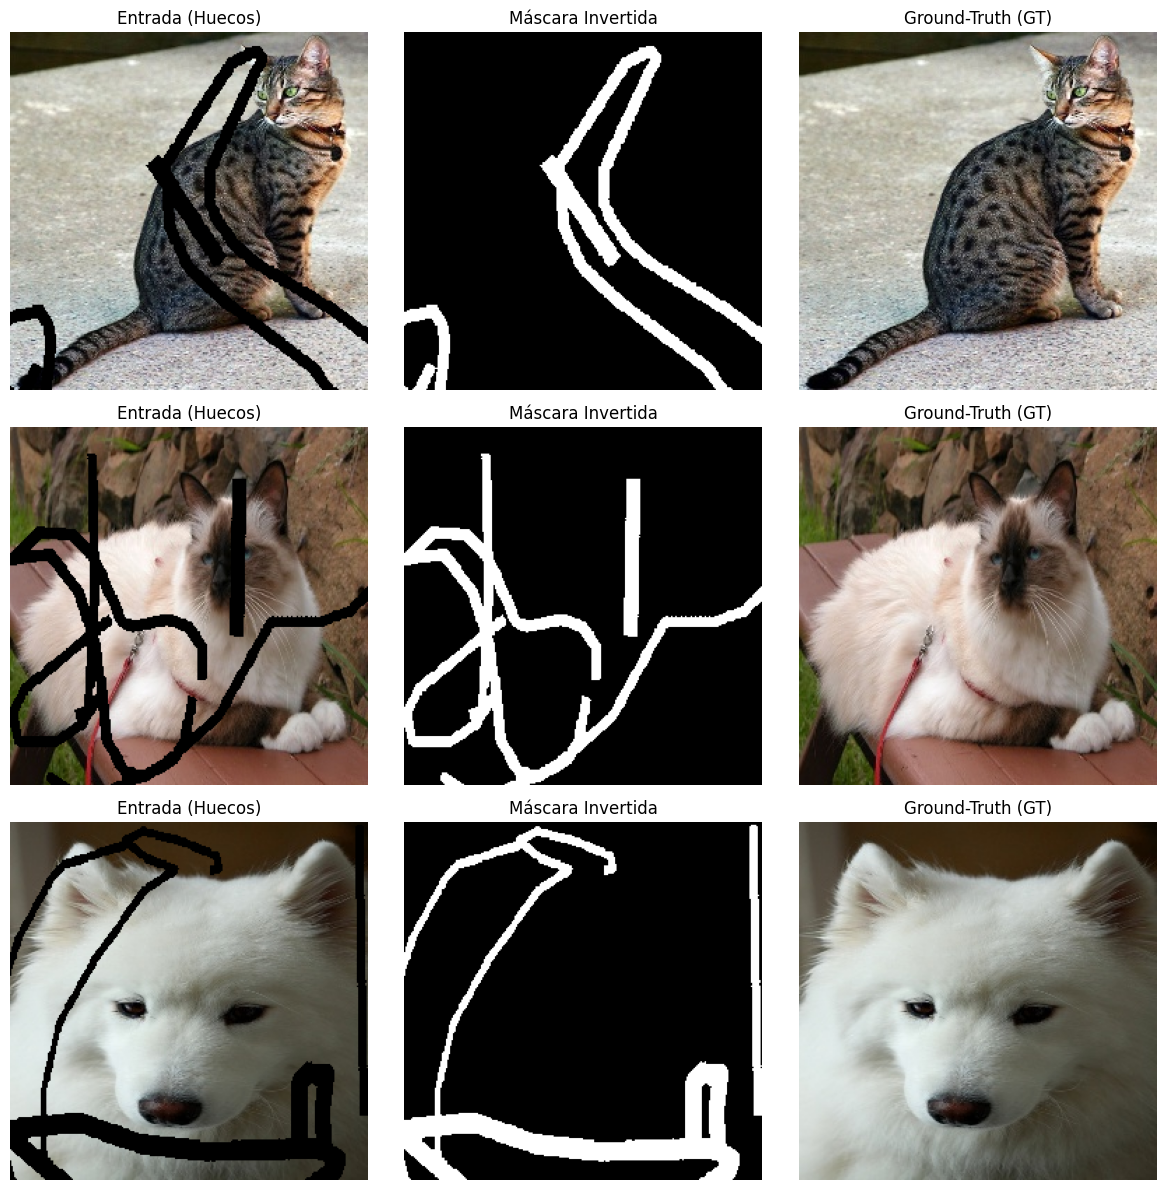

In [34]:
def visualize_data_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    for i in range(num_samples):
        img_masked, img_gt, mask_inv = dataset[i]

        # Transformar tensores a formato Numpy HWC para graficar
        img_masked_np = img_masked.permute(1, 2, 0).numpy()
        img_gt_np = img_gt.permute(1, 2, 0).numpy()
        mask_inv_np = mask_inv.squeeze().numpy()

        # Columna 1: Entrada con Huecos
        axes[i, 0].imshow(img_masked_np)
        axes[i, 0].set_title("Entrada (Huecos)")
        axes[i, 0].axis('off')

        # Columna 2: Máscara Invertida (Hueco en blanco)
        axes[i, 1].imshow(mask_inv_np, cmap='gray')
        axes[i, 1].set_title("Máscara Invertida")
        axes[i, 1].axis('off')

        # Columna 3: Ground Truth (Target)
        axes[i, 2].imshow(img_gt_np)
        axes[i, 2].set_title("Ground-Truth (GT)")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_data_samples(train_dataset, num_samples=3)

## 4. Diseño de la Arquitectura U-Net

In [35]:
class ResidualDoubleConv(nn.Module):
    """Bloque Convolucional Doble con Conexión Residual"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        # Si los canales cambian, adaptamos la identidad con una conv 1x1
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x) + self.shortcut(x))


class DoubleConv(nn.Module):
    """Bloque Convolucional Doble (Conv -> BatchNorm -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNetInpainting(nn.Module):
    """Arquitectura U-Net estándar adaptada para la reconstrucción de imágenes de 3 canales."""

    def __init__(self, in_ch=3, out_ch=3, base=64): # Changed base from 64 to 96
        super().__init__()
        # Encoder
        self.inc = ResidualDoubleConv(in_ch, base)
        self.down1 = torch.nn.Sequential(torch.nn.MaxPool2d(2), ResidualDoubleConv(base, base*2))
        self.down2 = torch.nn.Sequential(torch.nn.MaxPool2d(2), ResidualDoubleConv(base*2, base*4))
        self.down3 = torch.nn.Sequential(torch.nn.MaxPool2d(2), ResidualDoubleConv(base*4, base*8))
        self.down4 = torch.nn.Sequential(torch.nn.MaxPool2d(2), ResidualDoubleConv(base*8, base*16))

        # Decoder
        self.up1 = torch.nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.conv1 = ResidualDoubleConv(base*16, base*8)
        self.up2 = torch.nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.conv2 = ResidualDoubleConv(base*8, base*4)
        self.up3 = torch.nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv3 = ResidualDoubleConv(base*4, base*2)
        self.up4 = torch.nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.conv4 = ResidualDoubleConv(base*2, base)

        # self.outc = torch.nn.Conv2d(base, out_ch, 1)

        # Capa de salida lineal escalada mediante Sigmoid
        self.outc = nn.Sequential(
            nn.Conv2d(base, out_ch, kernel_size=1), # Changed 64 to base
            nn.Sigmoid()
        )


    def forward(self, x):
        # Camino del Encoder y guardado de skip connections
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Camino del Decoder con concatenación secuencial
        x = self.up1(x5)
        x = torch.cat([x4, x], dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat([x3, x], dim=1)
        x = self.conv2(x)

        x = self.up3(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv3(x)

        x = self.up4(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv4(x)

        return self.outc(x)

model = UNetInpainting().to(device)
print(f"Modelo instanciado correctamente en el dispositivo. Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")

Modelo instanciado correctamente en el dispositivo. Parámetros totales: 32,436,483


## 5. Entrenamiento y Evaluación

In [36]:
criterion = nn.MSELoss()
#criterion = nn.L1Loss() # Changed to L1Loss for potentially sharper results and better PSNR
optimizer = torch.optim.Adam(model.parameters(), lr=CFG['LR'])

# Added a learning rate scheduler to reduce LR on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def calculate_psnr(mse_loss):
    """Calcula el Peak Signal-to-Noise Ratio basado en el MSE."""
    if mse_loss == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse_loss))

history = {'train_loss': [], 'val_loss': [], 'val_psnr': []}

print("Iniciando el proceso de entrenamiento de la U-Net...")
for epoch in range(1, CFG['EPOCHS'] + 1):
    model.train()
    train_loss = 0.0

    for img_masked, img_gt, _ in train_loader:
        img_masked, img_gt = img_masked.to(device), img_gt.to(device)

        optimizer.zero_grad()
        outputs = model(img_masked)
        loss = criterion(outputs, img_gt)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * img_masked.size(0)

    train_loss /= len(train_loader.dataset)

    # Fase de validación periódica
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for img_masked, img_gt, _ in val_loader:
            img_masked, img_gt = img_masked.to(device), img_gt.to(device)
            outputs = model(img_masked)
            loss = criterion(outputs, img_gt)
            val_loss += loss.item() * img_masked.size(0)

    val_loss /= len(val_loader.dataset)
    current_psnr = calculate_psnr(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_psnr'].append(current_psnr)

    # Step the learning rate scheduler
    scheduler.step(val_loss)

    # if epoch % 5 == 0 or epoch == 1:
    print(f"Época [{epoch:02d}/{CFG['EPOCHS']}] -> Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f} | PSNR Validación: {current_psnr:.2f} dB")

torch.save(model.state_dict(), 'best_inpainting_unet.pth')
print("Entrenamiento completado. Pesos guardados como 'best_inpainting_unet.pth'")

Iniciando el proceso de entrenamiento de la U-Net...
Época [01/50] -> Train Loss: 0.02079 | Val Loss: 0.03399 | PSNR Validación: 14.69 dB
Época [02/50] -> Train Loss: 0.00647 | Val Loss: 0.00655 | PSNR Validación: 21.84 dB
Época [03/50] -> Train Loss: 0.00495 | Val Loss: 0.00387 | PSNR Validación: 24.13 dB
Época [04/50] -> Train Loss: 0.00417 | Val Loss: 0.00346 | PSNR Validación: 24.61 dB
Época [05/50] -> Train Loss: 0.00397 | Val Loss: 0.00313 | PSNR Validación: 25.05 dB
Época [06/50] -> Train Loss: 0.00377 | Val Loss: 0.00314 | PSNR Validación: 25.03 dB
Época [07/50] -> Train Loss: 0.00340 | Val Loss: 0.00250 | PSNR Validación: 26.02 dB
Época [08/50] -> Train Loss: 0.00349 | Val Loss: 0.00276 | PSNR Validación: 25.59 dB
Época [09/50] -> Train Loss: 0.00326 | Val Loss: 0.00462 | PSNR Validación: 23.35 dB
Época [10/50] -> Train Loss: 0.00390 | Val Loss: 0.00286 | PSNR Validación: 25.44 dB
Época [11/50] -> Train Loss: 0.00307 | Val Loss: 0.00244 | PSNR Validación: 26.13 dB
Época [12/50

## 6. Visualización de Resultados y Métricas

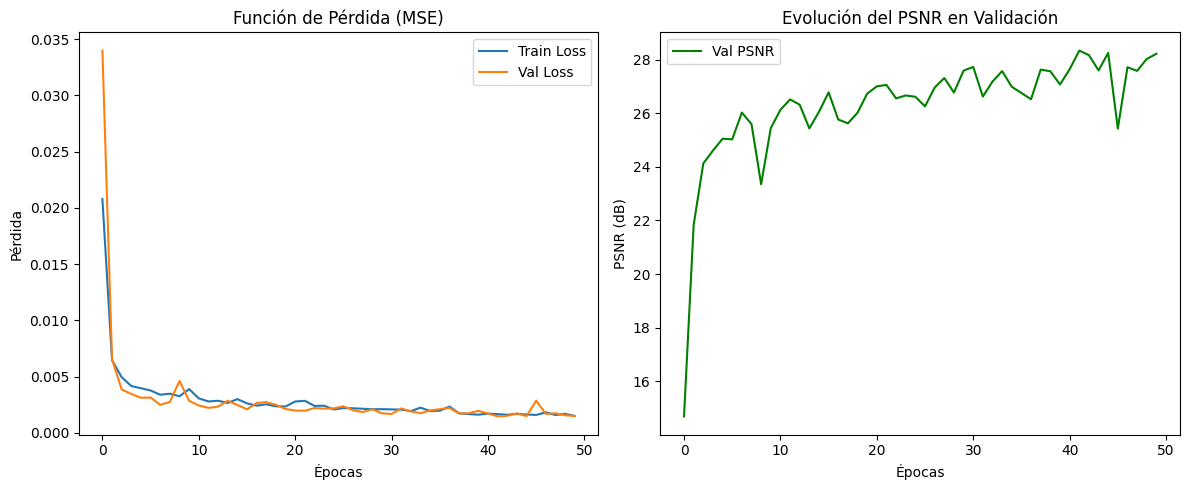

In [37]:
# Graficar las curvas de pérdida y la evolución del PSNR
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Función de Pérdida (MSE)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_psnr'], label='Val PSNR', color='green')
plt.title('Evolución del PSNR en Validación')
plt.xlabel('Épocas')
plt.ylabel('PSNR (dB)')
plt.legend()
plt.tight_layout()
plt.show()

* Se observa que la Función de Pérdida (MSE) disminuye rápidamente hacia valores cercanos a 0.0025 y continua disminuyendo cuando se incrementa el número de epocas.
* Se observa que el PSNR supera el umbral de 26.00db antes de 10 épocas, y luego se mantiene en incremento conforme aumenta el número de épocas, llegando al valor cercano a 30db para 50 épocas

## 7. Prueba

Evaluación y visualización de resultados en dataset de prueba

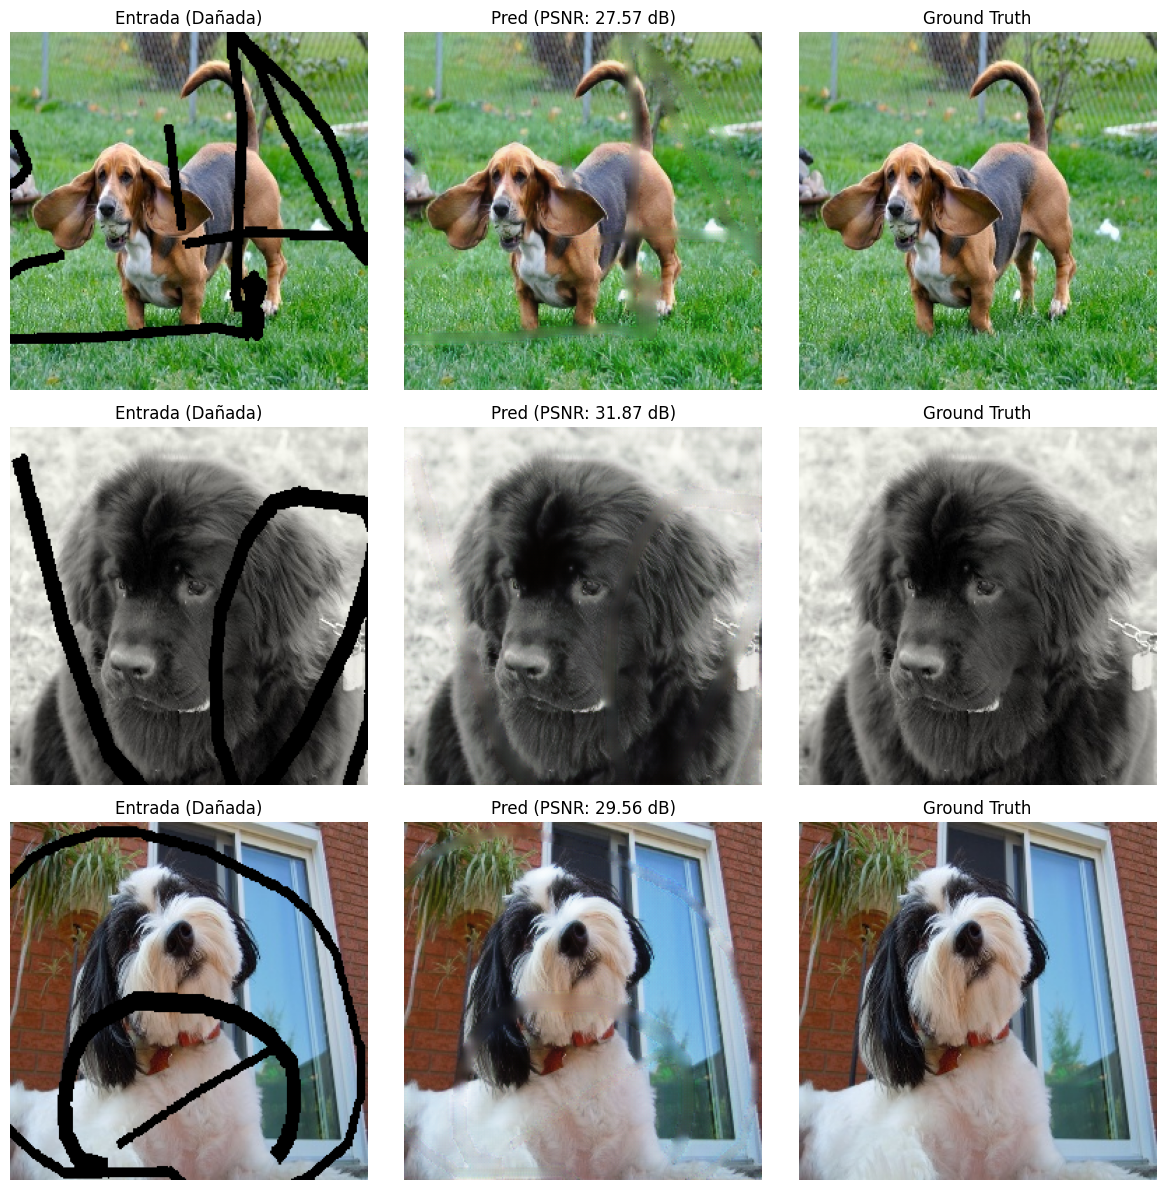

Métrica Media General PSNR en Muestras de Evaluación: 29.67 dB


In [38]:
def evaluate_and_visualize_results(model, dataset, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    test_psnr_list = []

    with torch.no_grad():
        for i in range(num_samples):
            img_masked, img_gt, mask_inv = dataset[i]

            # Pasar muestra por la red neuronal
            inputs = img_masked.unsqueeze(0).to(device)
            preds = model(inputs).squeeze(0).cpu()

            # Calcular el error cuadrático medio de la predicción frente al target
            mse = torch.mean((preds - img_gt) ** 2).item()
            psnr_sample = calculate_psnr(mse)
            test_psnr_list.append(psnr_sample)

            # Cambiar formatos a Numpy HWC para matplotlib
            img_masked_np = img_masked.permute(1, 2, 0).numpy()
            img_gt_np = img_gt.permute(1, 2, 0).numpy()
            preds_np = preds.permute(1, 2, 0).numpy()

            # Entrada
            axes[i, 0].imshow(img_masked_np)
            axes[i, 0].set_title("Entrada (Dañada)")
            axes[i, 0].axis('off')

            # Predicción / Reconstrucción de la U-Net
            axes[i, 1].imshow(preds_np)
            axes[i, 1].set_title(f"Pred (PSNR: {psnr_sample:.2f} dB)")
            axes[i, 1].axis('off')

            # Ground Truth
            axes[i, 2].imshow(img_gt_np)
            axes[i, 2].set_title("Ground Truth")
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Métrica Media General PSNR en Muestras de Evaluación: {np.mean(test_psnr_list):.2f} dB")

evaluate_and_visualize_results(model, test_dataset, num_samples=3)

## 8. Conclusiones

El uso de ResidulaDoubleCov permite mejorar el valor de PSNR en comparación a usar DoubleConv.

**DoubleConv**
- Época [25/50] -> Train Loss: 0.00250 | Val Loss: 0.00185 | PSNR Validación: 27.33 dB
- Métrica Media General PSNR en Muestras de Evaluación: 28.59 dB

**ResidualDoubleConv**
- Época [50/50] -> Train Loss: 0.00151 | Val Loss: 0.00151 | PSNR Validación: 28.22 dB
- Métrica Media General PSNR en Muestras de Evaluación: 29.67 dB

Agregar conexiones residuales (Residual Connections) dentro de cada bloque de la U-Net ayuda drásticamente a transferir los gradientes sin degradación, permitiendo que la red aprenda estructuras finas mucho más rápido dentro del límite de las 50 épocas.